# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository.  You have already used this set but this time I have removed  the first column. The set  `banknote_authentication.csv` can be found in the `data`  directory.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [2]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

In [3]:
data = pd.read_csv('data/banknote_authentication.csv' )

In [4]:
data.head()

,a1,a2,a3,counterfeit
0,12.3784,0.70403,-7.58360,0
1,8.1881,-3.13380,-2.52760,0
2,-10.8679,9.49260,-1.41160,1
3,-8.7903,7.97350,-0.45475,1
4,-5.5167,10.93900,-0.40820,1


In [5]:
seed = 31287
features = ['a1', 'a2', 'a3']

data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data['counterfeit'], random_state=seed)
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

pi1 = lbls_train.mean()
pi0 = 1 - pi1

## Problem 

### A.

Perform the Quadratic Discriminant Analysis on this set. Calculate the confusion matrix, AUC score and plot the ROC curve. 

QDA Confusion Matrix (normalized):
[[0.81967213 0.18032787]
 [0.28571429 0.71428571]]

QDA AUC: 0.8754


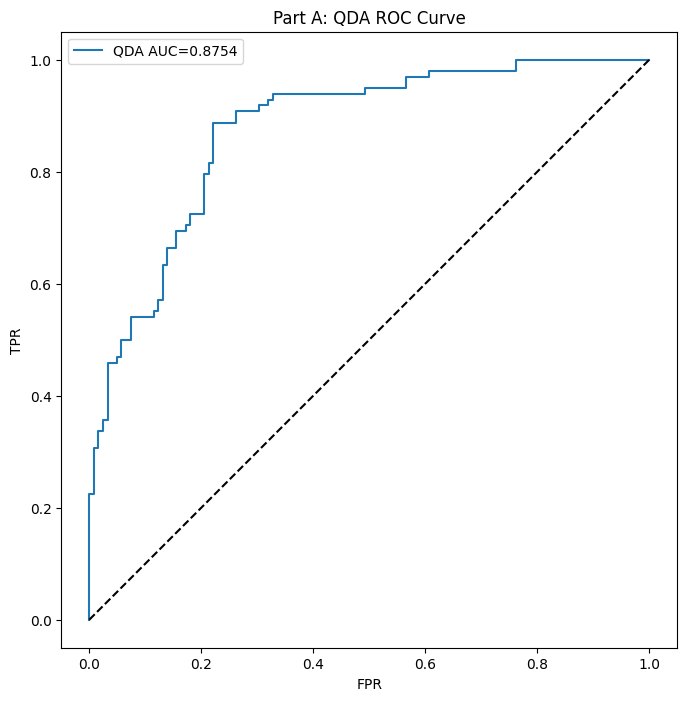

In [6]:
# Part A: Quadratic Discriminant Analysis
qda = QuadraticDiscriminantAnalysis()
qda.fit(data_train[features], lbls_train)

qda_proba_test = qda.predict_proba(data_test[features])[:, 1]
qda_pred_test = qda.predict(data_test[features])

print("QDA Confusion Matrix (normalized):")
print(confusion_matrix(lbls_test, qda_pred_test, normalize='true'))

qda_auc = roc_auc_score(lbls_test, qda_proba_test)
print(f"\nQDA AUC: {qda_auc:.4f}")

fprs_qda, tprs_qda, thds_qda = roc_curve(lbls_test, qda_proba_test)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_qda, tprs_qda, label=f'QDA AUC={qda_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Part A: QDA ROC Curve')
ax.legend()
plt.show()

### B.

Perform Gaussian Mixture Discriminant Analysis on this set as described in the `gaussian_mixture_model_EM_algorithm` notebook. Use two components for positives and two components for negatives. Calculate the confusion matrix, AUC score and plot the ROC curve. 

GMDA (2 components) Confusion Matrix (normalized):
[[0.91803279 0.08196721]
 [0.2755102  0.7244898 ]]

GMDA AUC: 0.9405


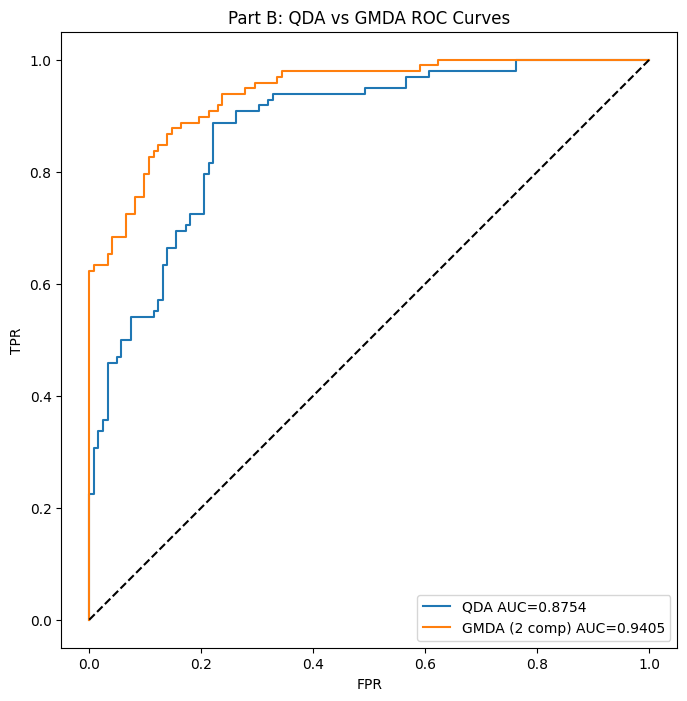

In [ ]:

def make_pdf(cmp):
    n_cmp = cmp.n_components
    dists = [st.multivariate_normal(cmp.means_[i], cmp.covariances_[i]) for i in range(n_cmp)]
    def pdf(x):
        p = 0.0
        for i in range(n_cmp):
            p += cmp.weights_[i] * dists[i].pdf(x)
        return p
    return pdf

def make_predict_proba(cmp0, cmp1, pi0=0.5, pi1=0.5):
    pdf0 = make_pdf(cmp0)
    pdf1 = make_pdf(cmp1)
    def p(x):
        p0 = pi0 * pdf0(x)
        p1 = pi1 * pdf1(x)
        return p1 / (p1 + p0)
    return p

# Fit GMMs
train_0 = data_train[lbls_train == 0][features].values
train_1 = data_train[lbls_train == 1][features].values

gm0 = GaussianMixture(n_components=2, random_state=seed).fit(train_0)
gm1 = GaussianMixture(n_components=2, random_state=seed).fit(train_1)

mgda = make_predict_proba(gm0, gm1, pi0=pi0, pi1=pi1)
mgda_test_proba = mgda(data_test[features].values)

mgda_pred_test = (mgda_test_proba > 0.5).astype(int)
print("GMDA (2 components) Confusion Matrix (normalized):")
print(confusion_matrix(lbls_test, mgda_pred_test, normalize='true'))

mgda_auc = roc_auc_score(lbls_test, mgda_test_proba)
print(f"\nGMDA AUC: {mgda_auc:.4f}")

fprs_mgda, tprs_mgda, _ = roc_curve(lbls_test, mgda_test_proba)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect(1.0)
ax.plot(fprs_qda, tprs_qda, label=f'QDA AUC={qda_auc:.4f}')
ax.plot(fprs_mgda, tprs_mgda, label=f'GMDA (2 comp) AUC={mgda_auc:.4f}')
ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.set_title('Part B: QDA vs GMDA ROC Curves')
ax.legend()
plt.show()

In [8]:
mgda_test_proba[:10]

array([2.90023652e-02, 4.18379264e-01, 1.38927404e-01, 2.42231557e-06,
       3.16099585e-01, 7.43992726e-01, 1.63577779e-01, 1.09496297e-01,
       3.65159988e-02, 2.34768750e-05])